In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb

import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

d:\ProgramData\Anaconda3\envs\ml-py39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pd.read_csv("SSD_InelasticSa.csv")
print("Total samples:", len(df))

# -----------------------------
# Event-based split
# -----------------------------
unique_events = df["event_number"].unique()

event_train, event_temp = train_test_split(
    unique_events, test_size=0.2, random_state=2
)
event_val, event_test = train_test_split(
    event_temp, test_size=0.5, random_state=2
)

df_train = df[df["event_number"].isin(event_train)].copy()
df_val   = df[df["event_number"].isin(event_val)].copy()
df_test  = df[df["event_number"].isin(event_test)].copy()

# =============================
# save event_number（mixed-effects）
# =============================
event_id_train = df_train["event_number"].values
event_id_val   = df_val["event_number"].values
event_id_test  = df_test["event_number"].values


core_features = ["Mw", "Rjb", "Vs30", "RY", "Period"]
y_column = "Sa"
id_cols = ["RSN", "event_number"]

missing_core = set(core_features) - set(df.columns)
assert len(missing_core) == 0, f"缺失核心特征: {missing_core}"

x_columns = core_features
print("Input features (core only):", x_columns)

for d in [df_train, df_val, df_test]:
    d.drop(columns=[c for c in id_cols if c in d.columns], inplace=True)

feature_names = x_columns


def preprocess(df, x_columns, y_column="Sa"):
    epsilon = 1e-8
    df = df.copy()

    if "Rjb" in x_columns:
        df["Rjb"] = np.log(df["Rjb"] + epsilon)

    if "Vs30" in x_columns:
        df["Vs30"] = np.log(df["Vs30"])

    # ln(Sa / g)
    df[y_column] = np.log((df[y_column] + epsilon) / 9.8)

    X = df[x_columns].to_numpy()
    y = df[y_column].to_numpy()

    return X, y


X_train, y_train = preprocess(df_train, x_columns, y_column)
X_val,   y_val   = preprocess(df_val,   x_columns, y_column)
X_test,  y_test  = preprocess(df_test,  x_columns, y_column)

print("Train / Val / Test:", len(X_train), len(X_val), len(X_test))


Total samples: 1954512
Input features (core only): ['Mw', 'Rjb', 'Vs30', 'RY', 'Period']
Train / Val / Test: 1415736 310716 228060


In [ ]:
def train_xgb_mixed_effects(
    X_train, y_train, event_id_train,
    X_val, y_val,
    params,
    n_iter=5
):
    """
    AI-based mixed-effects XGBoost
    ln(Y_ij) = f(x_ij) + eta_i + epsilon_ij
    """

    eta = np.zeros(len(y_train))

    for it in range(n_iter):
        print(f"\n[Mixed-effects iteration {it+1}/{n_iter}]")

        # Step 1: fix eta
        y_tilde = y_train - eta

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_train, y_tilde,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Step 2: update event term
        y_pred = model.predict(X_train)
        residual = y_train - y_pred

        eta_event = (
            pd.DataFrame({
                "event": event_id_train,
                "residual": residual
            })
            .groupby("event")["residual"]
            .mean()
        )

        eta = pd.Series(event_id_train).map(eta_event).to_numpy()
        tau = eta_event.std()

        print(f"  Estimated tau (between-event std): {tau:.4f}")

    return model, eta_event


In [4]:
def objective(trial):
    params = {
        "n_estimators": 200,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "min_child_weight": trial.suggest_int("min_child_weight", 5, 30),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1e-1, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),

        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "random_state": 0,
        "n_jobs": -1
    }

    model, _ = train_xgb_mixed_effects(
        X_train, y_train, event_id_train,
        X_val, y_val,
        params,
        n_iter=3
    )

    y_val_pred = model.predict(X_val)
    return mean_squared_error(y_val, y_val_pred)


In [7]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)
print("Best RMSE:", study.best_value)

best_params = study.best_params.copy()

best_params.update({
    "n_estimators": 300,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "random_state": 0,
    "n_jobs": -1,
})



[I 2026-02-07 20:18:50,525] A new study created in memory with name: no-name-26e3027a-66f2-447c-addc-0658d06a2195



[Mixed-effects iteration 1/3]
  Estimated tau (between-event std): 0.0733

[Mixed-effects iteration 2/3]
  Estimated tau (between-event std): 0.1218

[Mixed-effects iteration 3/3]


[I 2026-02-07 20:19:48,013] Trial 0 finished with value: 0.7824740855049943 and parameters: {'learning_rate': 0.19324574550218698, 'max_depth': 8, 'subsample': 0.9965012920331154, 'colsample_bytree': 0.8061254764794362, 'min_child_weight': 16, 'gamma': 0.887245141023254, 'reg_alpha': 7.613532616109993e-08, 'reg_lambda': 0.7485979283601074}. Best is trial 0 with value: 0.7824740855049943.


  Estimated tau (between-event std): 0.1567

[Mixed-effects iteration 1/3]
  Estimated tau (between-event std): 0.2728

[Mixed-effects iteration 2/3]
  Estimated tau (between-event std): 0.3456

[Mixed-effects iteration 3/3]


[I 2026-02-07 20:20:37,773] Trial 1 finished with value: 0.7464184695829851 and parameters: {'learning_rate': 0.05311581362141369, 'max_depth': 5, 'subsample': 0.6897684273804987, 'colsample_bytree': 0.8450380265913202, 'min_child_weight': 18, 'gamma': 4.462159690829565, 'reg_alpha': 9.903178404486596e-06, 'reg_lambda': 0.002870537491293433}. Best is trial 1 with value: 0.7464184695829851.


...

  Estimated tau (between-event std): 0.3890

[Mixed-effects iteration 1/3]
  Estimated tau (between-event std): 0.2720

[Mixed-effects iteration 2/3]
  Estimated tau (between-event std): 0.4155

[Mixed-effects iteration 3/3]


[I 2026-02-07 20:45:30,243] Trial 28 finished with value: 0.8270277778345402 and parameters: {'learning_rate': 0.02028803681976551, 'max_depth': 8, 'subsample': 0.9059168209763588, 'colsample_bytree': 0.6238891396641681, 'min_child_weight': 23, 'gamma': 0.9766239749844781, 'reg_alpha': 2.913511036555792e-08, 'reg_lambda': 0.008616298249872301}. Best is trial 24 with value: 0.667461589667566.


  Estimated tau (between-event std): 0.5266

[Mixed-effects iteration 1/3]
  Estimated tau (between-event std): 0.2209

[Mixed-effects iteration 2/3]
  Estimated tau (between-event std): 0.3191

[Mixed-effects iteration 3/3]


[I 2026-02-07 20:46:32,009] Trial 29 finished with value: 0.6688286582769579 and parameters: {'learning_rate': 0.027151782155695428, 'max_depth': 8, 'subsample': 0.8236786821016543, 'colsample_bytree': 0.6011209122427302, 'min_child_weight': 23, 'gamma': 0.5851577084696348, 'reg_alpha': 4.54703801862104e-08, 'reg_lambda': 0.003303523623704531}. Best is trial 24 with value: 0.667461589667566.


  Estimated tau (between-event std): 0.3737
Best params: {'learning_rate': 0.027624924521269523, 'max_depth': 8, 'subsample': 0.7655293459269518, 'colsample_bytree': 0.6309514712728137, 'min_child_weight': 28, 'gamma': 0.9034688317486501, 'reg_alpha': 4.43893101614895e-06, 'reg_lambda': 0.09694838071265838}
Best RMSE: 0.667461589667566


In [8]:
_, eta_train_event = train_xgb_mixed_effects(
    X_train, y_train, event_id_train,
    X_val, y_val,
    best_params,
    n_iter=5
)



[Mixed-effects iteration 1/5]
  Estimated tau (between-event std): 0.1821

[Mixed-effects iteration 2/5]
  Estimated tau (between-event std): 0.2648

[Mixed-effects iteration 3/5]
  Estimated tau (between-event std): 0.3047

[Mixed-effects iteration 4/5]
  Estimated tau (between-event std): 0.3322

[Mixed-effects iteration 5/5]
  Estimated tau (between-event std): 0.3509


In [10]:
# -----------------------------
# 将事件项映射回训练样本
# -----------------------------
eta_train = pd.Series(event_id_train).map(eta_train_event).to_numpy()
y_tilde_final = y_train - eta_train

# -----------------------------
# 用 XGBoost 训练最终 fixed-effects 模型
# -----------------------------
final_model = xgb.XGBRegressor(**best_params)


final_model.fit(
    X_train,
    y_tilde_final,
    eval_set=[(X_val, y_val)],
    verbose=True
)


[0]	validation_0-rmse:7.28807
[1]	validation_0-rmse:7.08914
[2]	validation_0-rmse:6.91347
[3]	validation_0-rmse:6.73638
[4]	validation_0-rmse:6.55090
[5]	validation_0-rmse:6.38356
[6]	validation_0-rmse:6.20897
[7]	validation_0-rmse:6.05663
[8]	validation_0-rmse:5.89752
[9]	validation_0-rmse:5.72869
[10]	validation_0-rmse:5.57322
[11]	validation_0-rmse:5.42265
[12]	validation_0-rmse:5.28088
[13]	validation_0-rmse:5.15273
[14]	validation_0-rmse:5.02853
[15]	validation_0-rmse:4.90328
[16]	validation_0-rmse:4.78977
[17]	validation_0-rmse:4.67300
[18]	validation_0-rmse:4.53794
[19]	validation_0-rmse:4.42666
[20]	validation_0-rmse:4.31167
[21]	validation_0-rmse:4.19854
[22]	validation_0-rmse:4.07848
[23]	validation_0-rmse:3.98335
[24]	validation_0-rmse:3.89121
[25]	validation_0-rmse:3.80572
[26]	validation_0-rmse:3.71507
[27]	validation_0-rmse:3.61018
[28]	validation_0-rmse:3.51969
[29]	validation_0-rmse:3.43982
[30]	validation_0-rmse:3.34367
[31]	validation_0-rmse:3.26600
[32]	validation_0-

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6309514712728137, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=0.9034688317486501, gpu_id=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.027624924521269523, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=28, missing=nan, monotone_constraints=None,
             n_estimators=300, n_jobs=-1, num_parallel_tree=None,
             predictor=None, random_state=0, ...)

In [ ]:
# Predicting fixed effects
y_fixed_test = final_model.predict(X_test)

eta_test = (
    pd.Series(event_id_test)
    .map(eta_train_event)
    .fillna(0.0)
    .to_numpy()
)

y_pred_test = y_fixed_test + eta_test

In [12]:
results = {
    "MSE": mean_squared_error(y_test, y_pred_test),
    "MAE": mean_absolute_error(y_test, y_pred_test),
    "R2":  r2_score(y_test, y_pred_test)
}

print(
    "[Mixed-effects XGBoost] "
    f"MSE={results['MSE']:.4f}, "
    f"MAE={results['MAE']:.4f}, "
    f"R2={results['R2']:.4f}"
)

[Mixed-effects XGBoost] MSE=0.8332, MAE=0.7172, R2=0.9266


In [ ]:
import pandas as pd
import numpy as np

df_res = pd.DataFrame({
    "event_number": event_id_test,
    "y_true": y_test,
    "y_pred": y_pred_test
})

df_res["residual"] = df_res["y_true"] - df_res["y_pred"]
bias = df_res["residual"].mean()
# -----------------------------
# Between-event residual (η)
# -----------------------------
eta_test = df_res.groupby("event_number")["residual"].mean()

# -----------------------------
# Within-event residual (ε)
# -----------------------------
df_res["eta"] = df_res["event_number"].map(eta_test)
df_res["epsilon"] = df_res["residual"] - df_res["eta"]

# -----------------------------
# Variability components
# -----------------------------
tau = eta_test.std()
phi = df_res["epsilon"].std()
sigma = np.sqrt(tau**2 + phi**2)

print(f"Overall Bias:        {bias:.4f}")
print(f"tau (between-event): {tau:.4f}")
print(f"phi (within-event):  {phi:.4f}")
print(f"sigma (total):       {sigma:.4f}")

tau (between-event): 0.6914
phi (within-event):  0.7332
sigma (total):       1.0078


In [ ]:
def residual_decomposition(y_true, y_pred, event_id):
    """
    返回：
    df_res: record-level residual DataFrame
    eta_event: event-level between-event residual
    """
    df_res = pd.DataFrame({
        "event_number": event_id,
        "y_true": y_true,
        "y_pred": y_pred
    })

    df_res["residual"] = df_res["y_true"] - df_res["y_pred"]

    # between-event
    eta_event = df_res.groupby("event_number")["residual"].mean()

    # within-event
    df_res["eta"] = df_res["event_number"].map(eta_event)
    df_res["epsilon"] = df_res["residual"] - df_res["eta"]

    return df_res, eta_event

In [ ]:
y_fixed_train = final_model.predict(X_train)

eta_train = (
    pd.Series(event_id_train)
    .map(eta_train_event)
    .to_numpy()
)

y_pred_train = y_fixed_train + eta_train

y_fixed_val = final_model.predict(X_val)

eta_val = (
    pd.Series(event_id_val)
    .map(eta_train_event)
    .fillna(0.0)
    .to_numpy()
)

y_pred_val = y_fixed_val + eta_val

y_fixed_test = final_model.predict(X_test)

eta_test_pred = (
    pd.Series(event_id_test)
    .map(eta_train_event)
    .fillna(0.0)
    .to_numpy()
)

y_pred_test = y_fixed_test + eta_test_pred

df_res_train, eta_train_res = residual_decomposition(
    y_train, y_pred_train, event_id_train
)

df_res_val, eta_val_res = residual_decomposition(
    y_val, y_pred_val, event_id_val
)
df_res_test, eta_test_res = residual_decomposition(
    y_test, y_pred_test, event_id_test
)

df_res_all = pd.concat(
    [
        df_res_train.assign(split="Train"),
        df_res_val.assign(split="Val"),
        df_res_test.assign(split="Test")
    ],
    ignore_index=True
)

eta_all = df_res_all.groupby("event_number")["residual"].mean()

Mw_all = np.concatenate([
    X_train[:, x_columns.index("Mw")],
    X_val[:,   x_columns.index("Mw")],
    X_test[:,  x_columns.index("Mw")]
])

event_id_all = np.concatenate([
    event_id_train,
    event_id_val,
    event_id_test
])

df_event_all = pd.DataFrame({
    "event_number": event_id_all,
    "Mw": Mw_all
})

mw_event_all = df_event_all.groupby("event_number")["Mw"].mean()
eta_plot_all = eta_all.loc[mw_event_all.index]



In [ ]:
X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])
y_pred_all = np.concatenate([y_pred_train, y_pred_val, y_pred_test])
event_id_all = np.concatenate([event_id_train, event_id_val, event_id_test])

print("All dataset size:", len(X_all))


All dataset size: 1954512


In [23]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }
metrics_train = regression_metrics(y_train, y_pred_train)
metrics_val = regression_metrics(y_val, y_pred_val)
metrics_test = regression_metrics(y_test, y_pred_test)
df_metrics = pd.DataFrame.from_dict(
    {
        "Train": metrics_train,
        "Val": metrics_val,
        "Test": metrics_test
    },
    orient="index"
)

print(df_metrics)


             R2      RMSE       MAE
Train  0.974060  0.564128  0.440766
Val    0.926318  0.827133  0.648089
Test   0.926648  0.912789  0.717183


In [ ]:
# -------------------------
# Permutation Importance
# -------------------------
from sklearn.inspection import permutation_importance

result = permutation_importance(
    final_model, 
    X_test, y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1
)

df_perm = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean,
    "Std": result.importances_std
}).sort_values("Importance", ascending=True).set_index("Feature")

print("\n=== Feature Importances (Permutation) ===")
print(df_perm)



=== Feature Importances (Permutation) ===
         Importance       Std
Feature                      
Vs30       0.021572  0.000171
RY         0.042218  0.000142
Rjb        0.255868  0.000751
Period     0.741993  0.001959
Mw         0.894186  0.001596


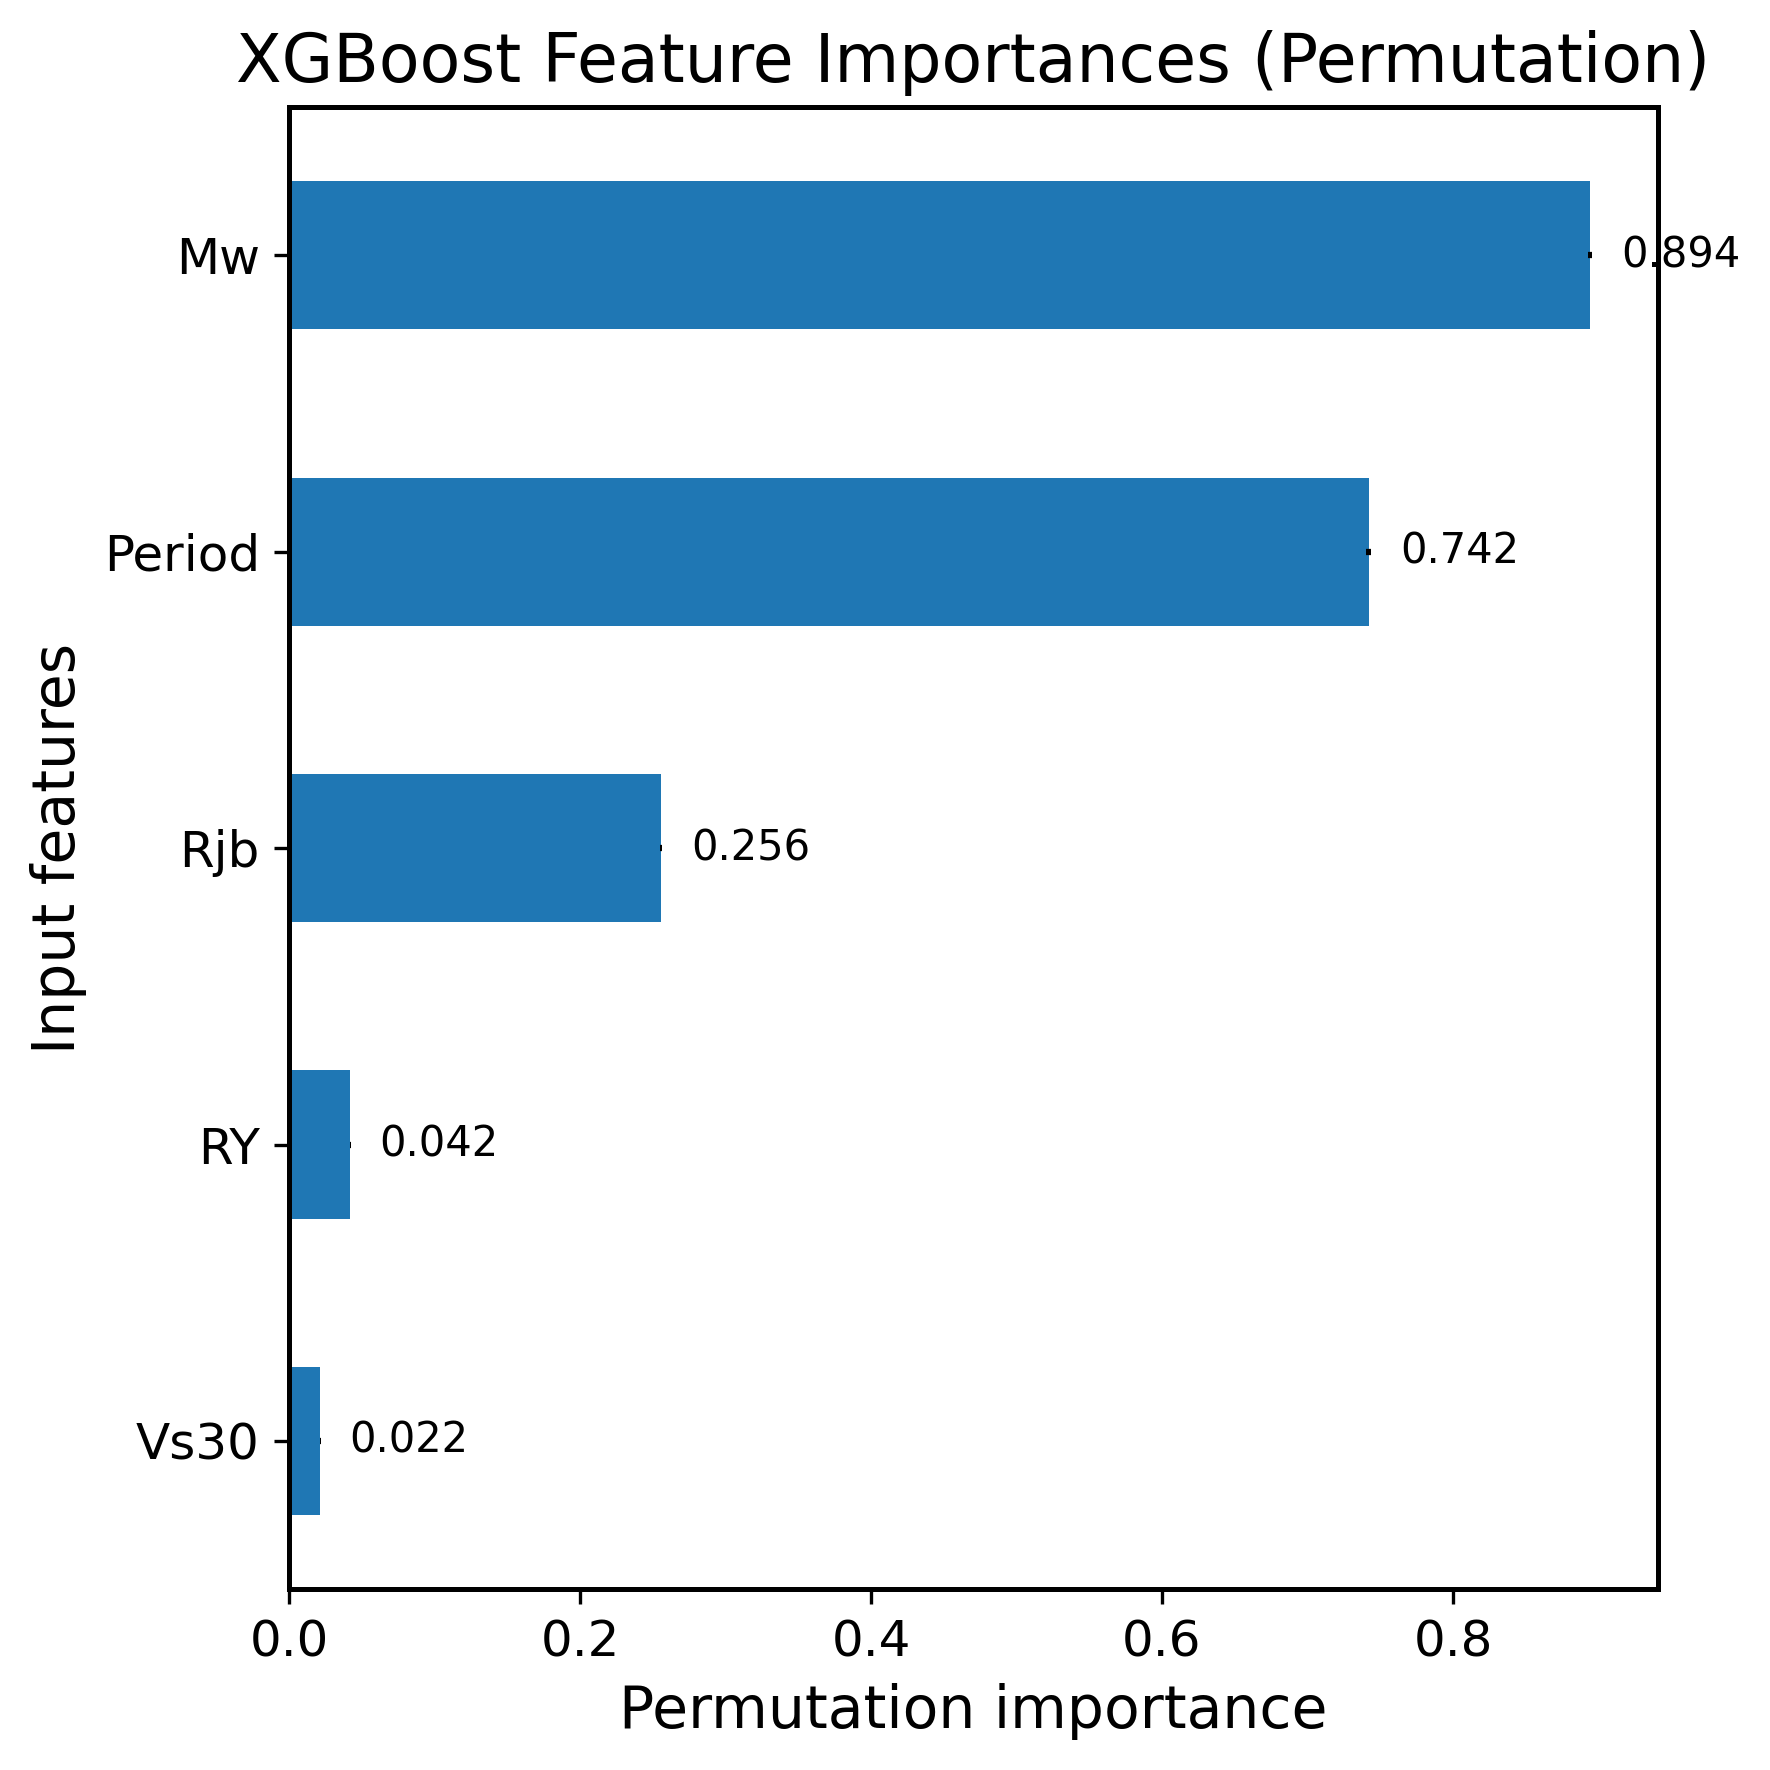

In [ ]:
# ---------- Plot：Permutation ----------
plt.figure(figsize=(6, 6), dpi=300, facecolor='white')
ax = df_perm["Importance"].plot.barh(
    xerr=df_perm["Std"], 
)

for i, (value, std) in enumerate(zip(df_perm["Importance"], df_perm["Std"])):
    ax.text(value + std + 0.02, i, f"{value:.3f}", 
            va='center', fontsize=10, color="black")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.xlabel("Permutation importance", fontsize=14, color="black")
plt.ylabel("Input features", fontsize=14, color="black")
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")
plt.title("XGBoost Feature Importances (Permutation)", fontsize=16, color="black")

ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()

plt.show()



In [ ]:
import shap
import matplotlib.pyplot as plt

model = final_model

X_data = pd.DataFrame(X_test, columns=x_columns) 

print("\n=== SHAP analysis for XGBoost ===")

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_data)
print("\n=== SHAP analysis for XGBoost Finished ===")
mean_abs_shap = np.abs(shap_values).mean(0)
print(mean_abs_shap)


=== SHAP analysis for XGBoost ===

=== SHAP analysis for XGBoost Finished ===
[2.1966517  0.9233201  0.27873963 0.3622356  1.7049147 ]


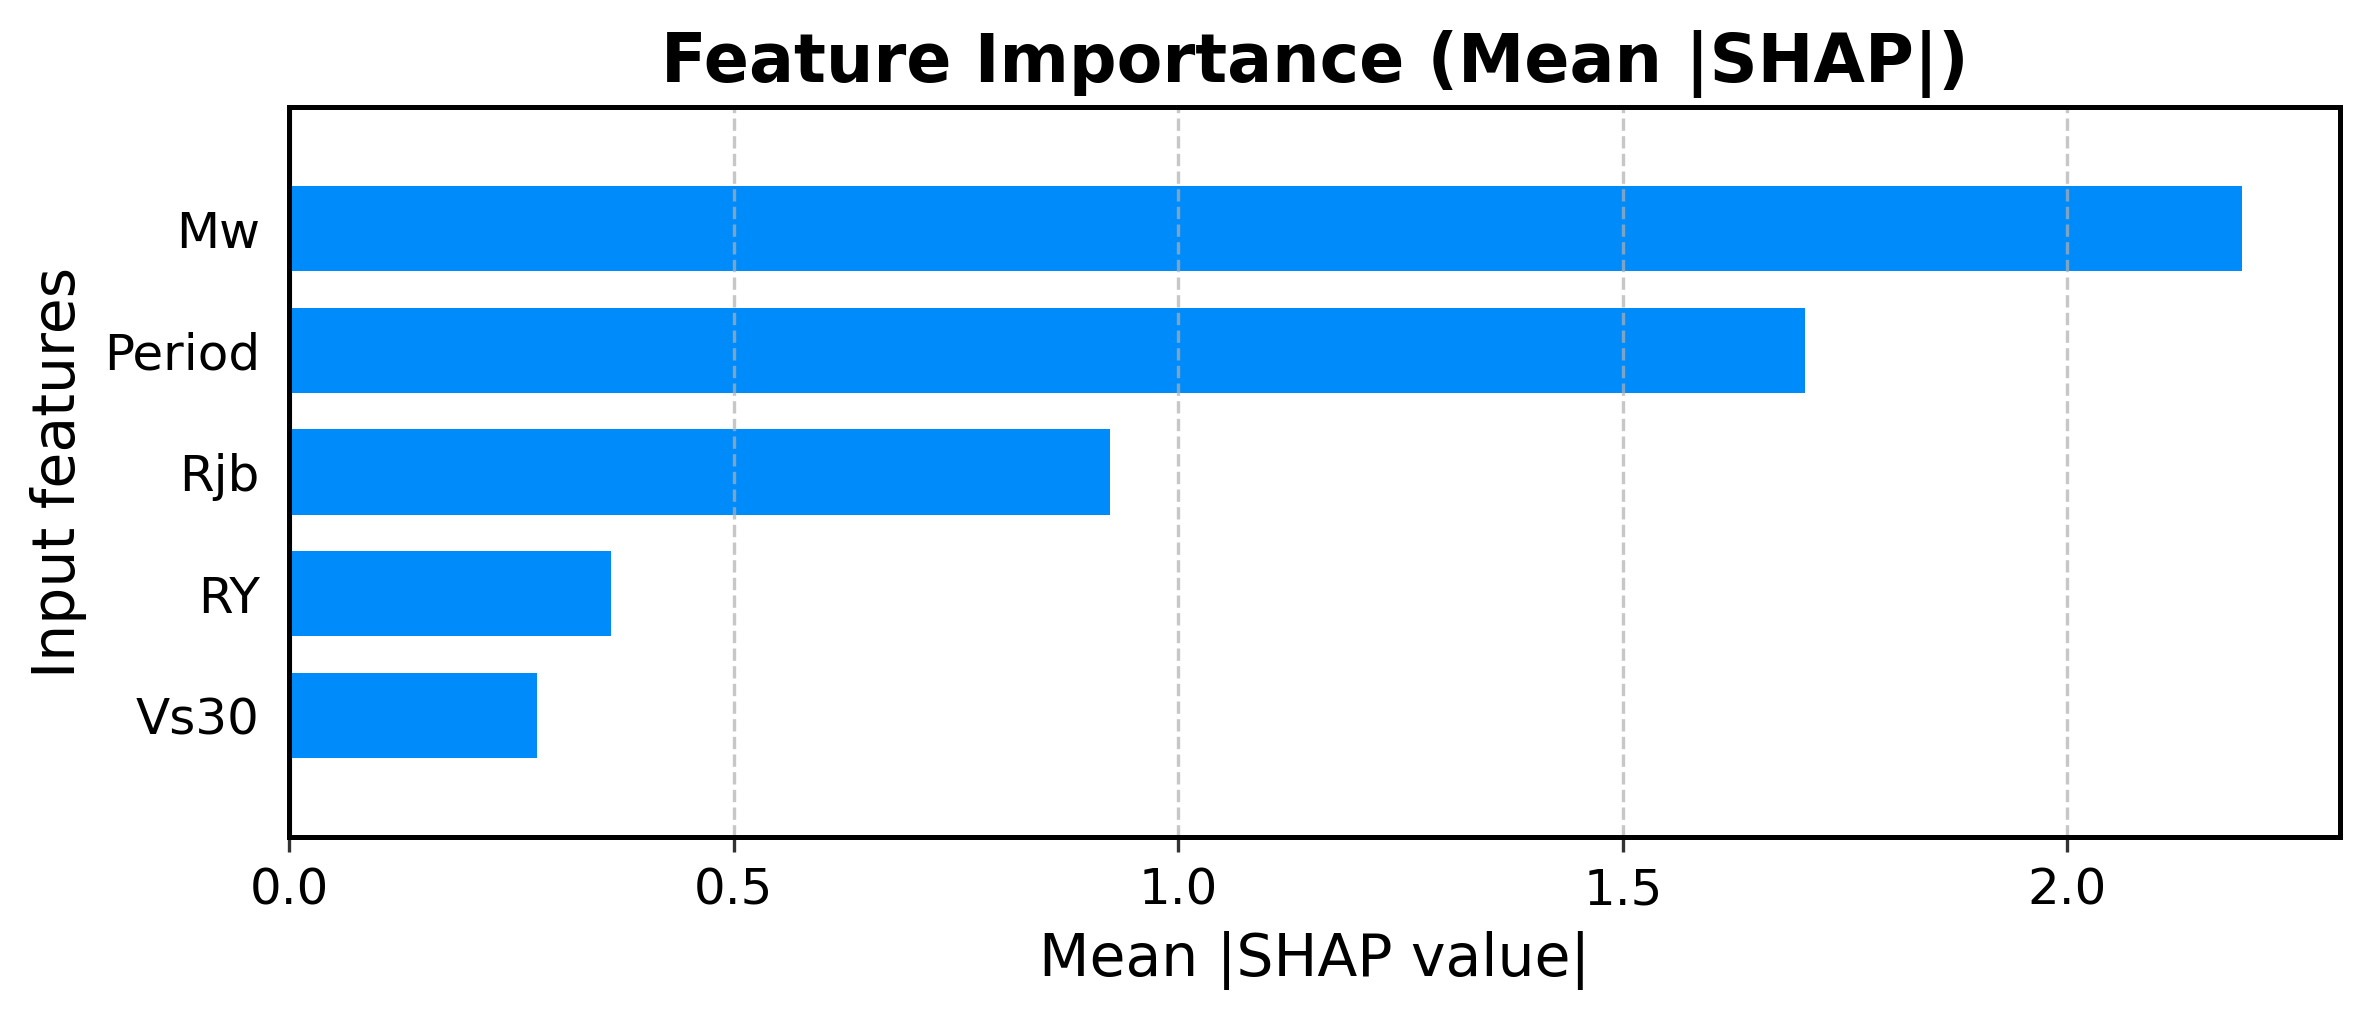

In [ ]:

plt.figure(figsize=(8, 8), dpi=300, facecolor='white')

shap.summary_plot(
    shap_values, 
    X_data, 
    plot_type="bar", 
    show=False,
    max_display=15, 
    # color='#4C72B0'
)

ax = plt.gca()

ax.set_facecolor('white') 

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color('black')

plt.title("Feature Importance (Mean |SHAP|)", fontsize=16, fontweight='bold', color='black')
plt.xlabel("Mean |SHAP value|", fontsize=14, color='black')
plt.ylabel("Input features", fontsize=14, color='black')

plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

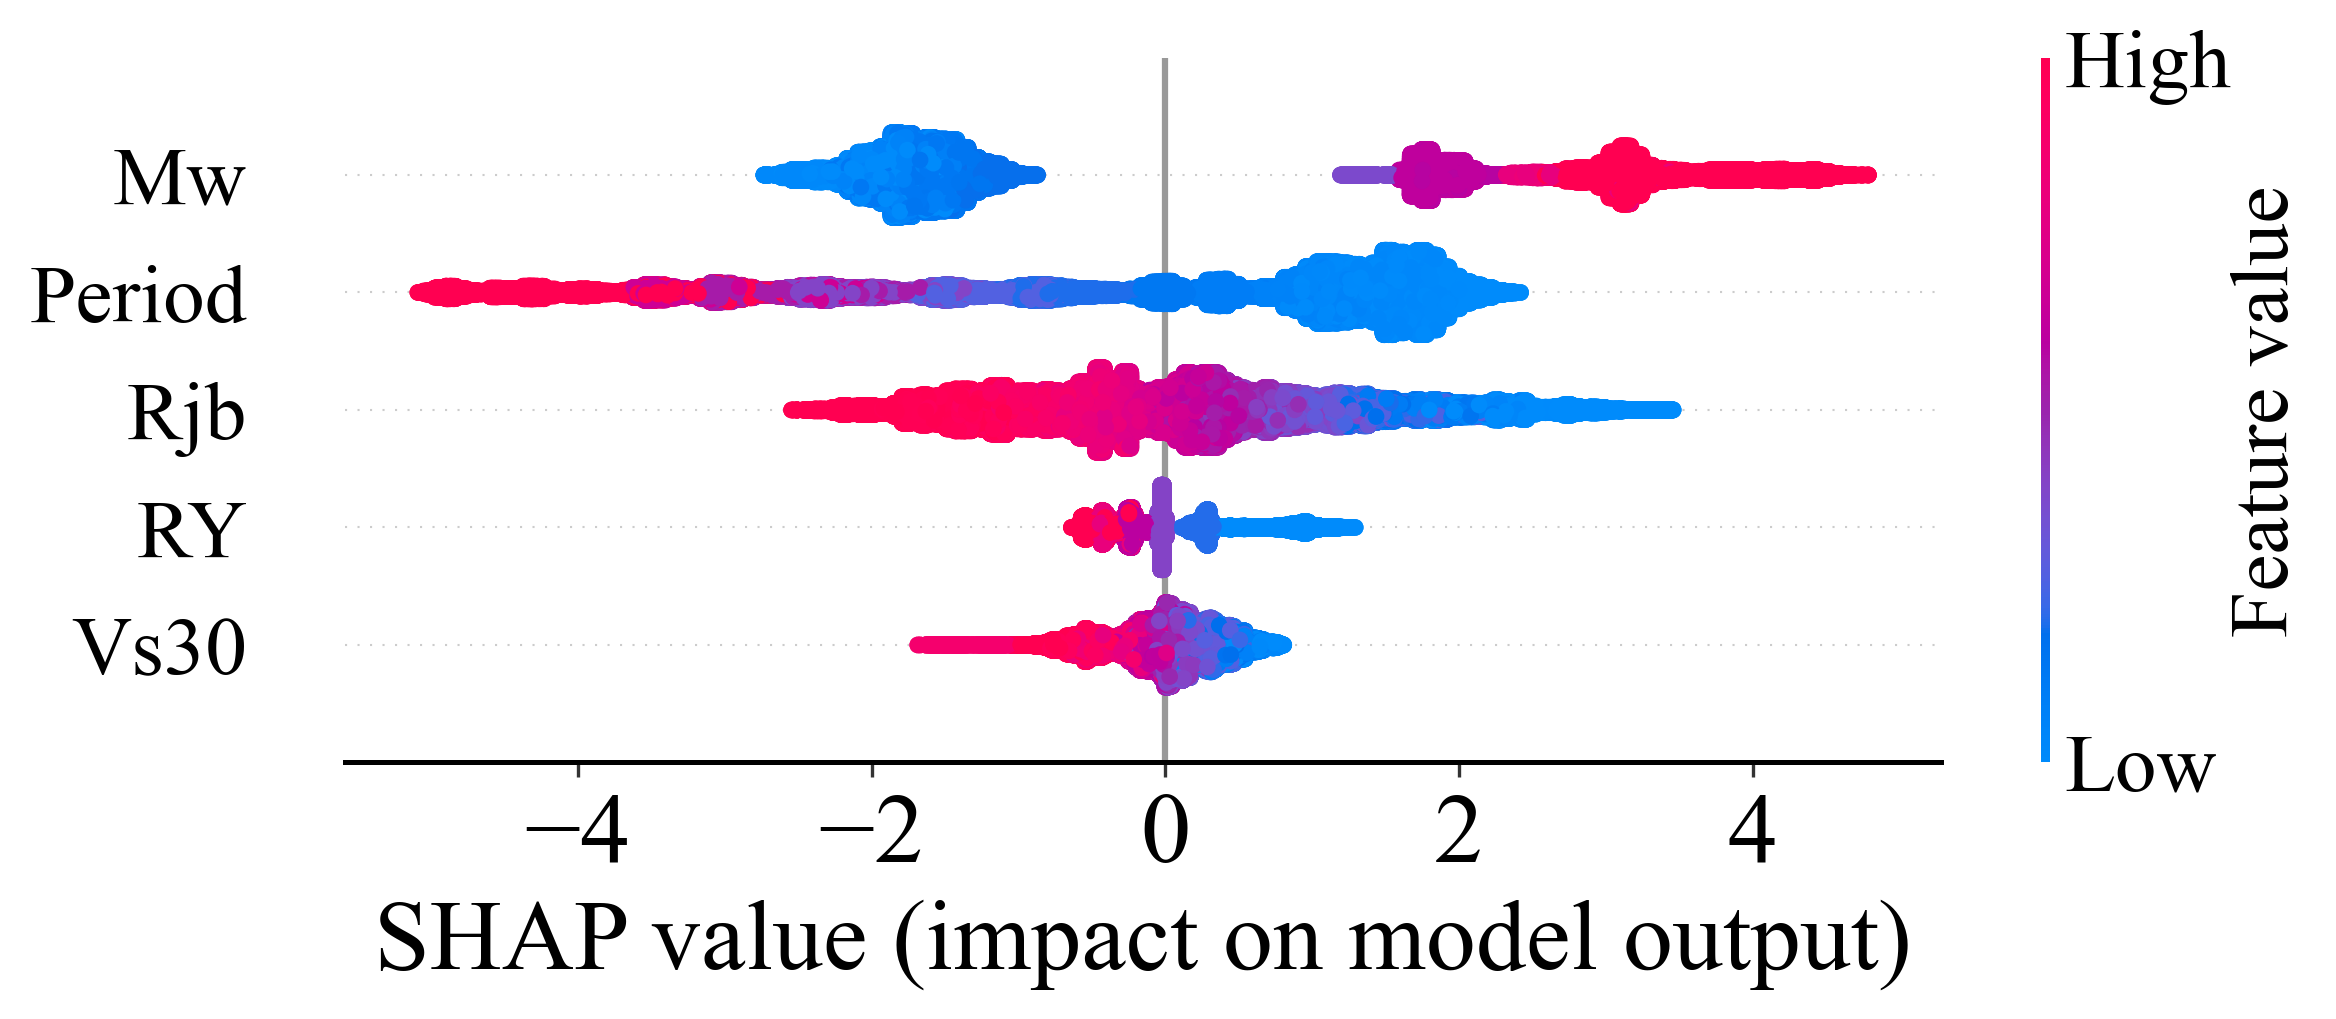

In [ ]:
plt.figure(figsize=(8, 6), dpi=300, facecolor='white')

shap.summary_plot(
    shap_values, 
    X_data, 
    plot_type="dot", 
    show=False,
    max_display=20,
    # cmap=plt.cm.coolwarm 
)
ax = plt.gca()
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color('black')


plt.xlabel("SHAP value (impact on model output)", fontsize=24, color='black')

plt.xticks(fontsize=24, color='black')
plt.yticks(fontsize=20, color='black')

cbar = plt.gcf().axes[-1]  
cbar.set_ylabel("Feature value", fontsize=20, color='black')
cbar.tick_params(labelsize=20, colors='black')

plt.tight_layout()
plt.show()

In [ ]:
y_pred_test = final_model.predict(X_test)

y_test_Sa = np.exp(y_test)
y_pred_Sa = np.exp(y_pred_test)

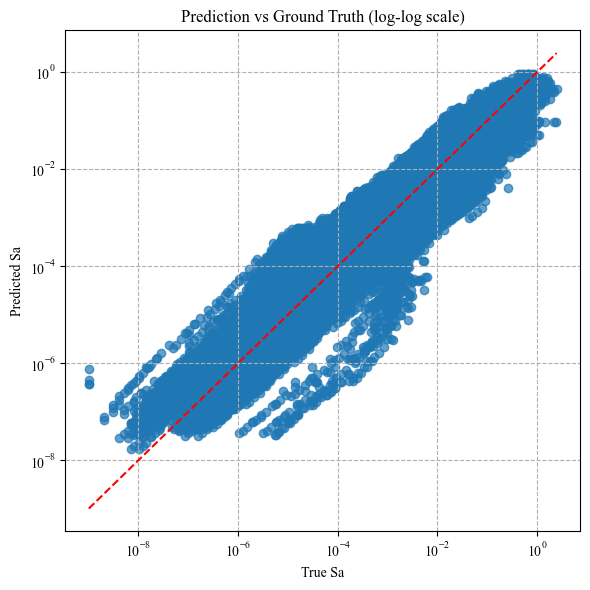

In [ ]:
y_true = y_test_Sa
y_pred_np = y_pred_Sa
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred_np, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--') 
plt.xscale('log')
plt.yscale('log')
plt.xlabel('True Sa')
plt.ylabel('Predicted Sa')
plt.title('Prediction vs Ground Truth (log-log scale)')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()